In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.layers import Input, Dense

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder

from scipy import stats
from scipy.ndimage import median_filter

In [142]:
titanic_data = sns.load_dataset('titanic')

titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Изучаем данные

In [143]:
titanic_data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [144]:
titanic_data.info() # int65, object, float64, category, bool

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


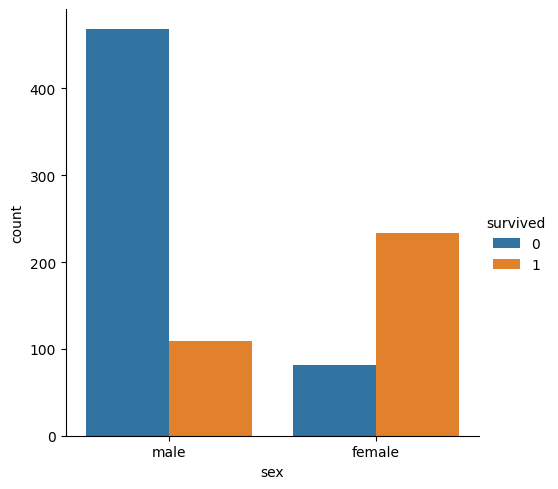

In [145]:
sns.catplot(x ="sex", hue ="survived", 
kind ="count", data = titanic_data);

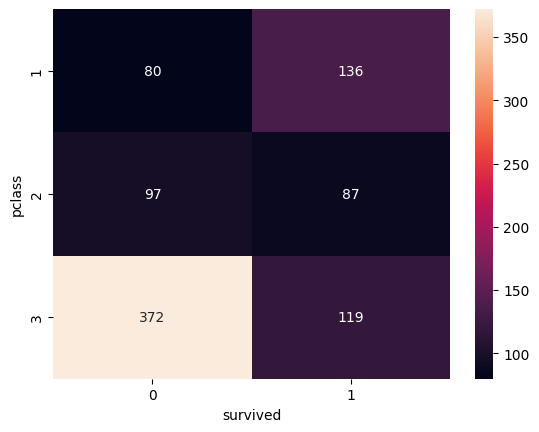

In [146]:
group = titanic_data.groupby(['pclass', 'survived']) 
pclass_survived = group.size().unstack() 

sns.heatmap(pclass_survived, annot = True, fmt ="d");

<Axes: xlabel='sex', ylabel='age'>

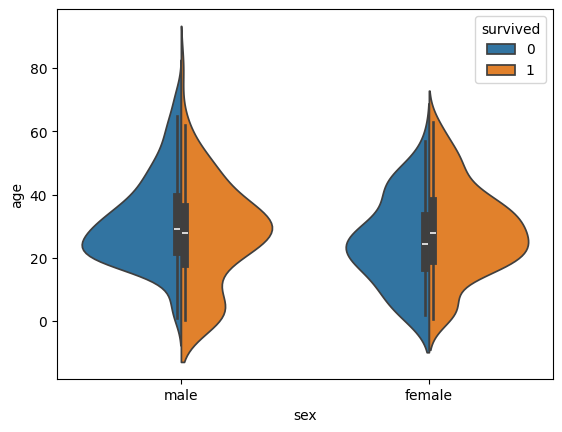

In [147]:
sns.violinplot(x ="sex", y ="age", hue ="survived", 
data = titanic_data, split = True)

<Figure size 1000x600 with 0 Axes>

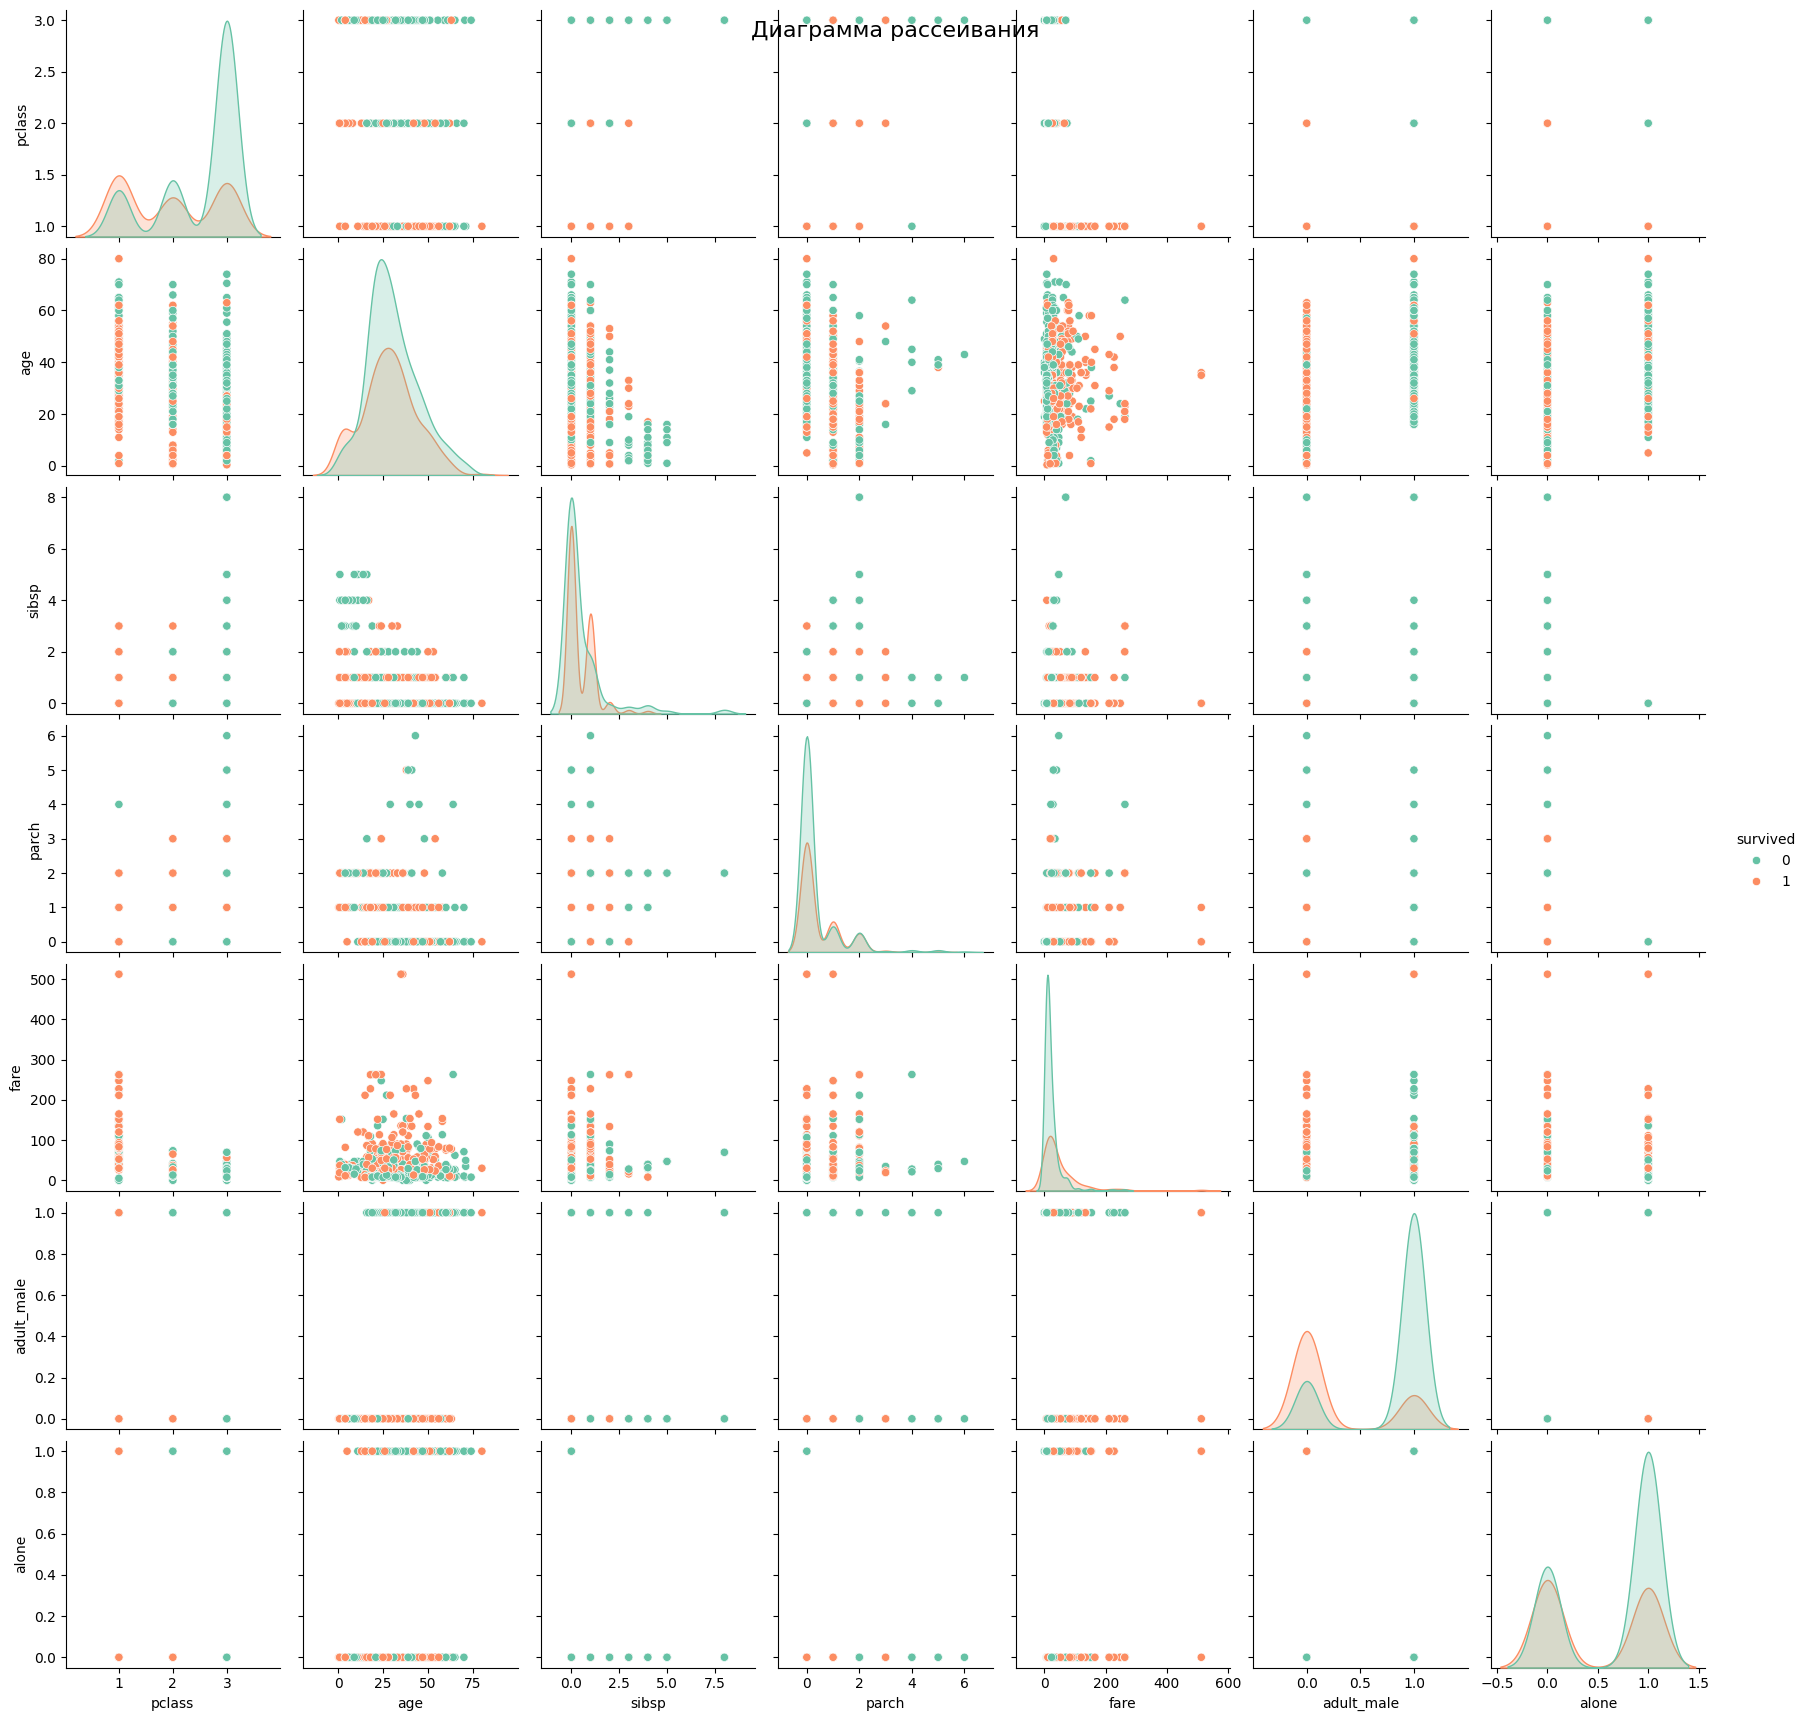

In [148]:
plt.figure(figsize=(10, 6))
sns.pairplot(titanic_data, hue="survived", palette="Set2")
plt.suptitle('Диаграмма рассеивания', size=16);

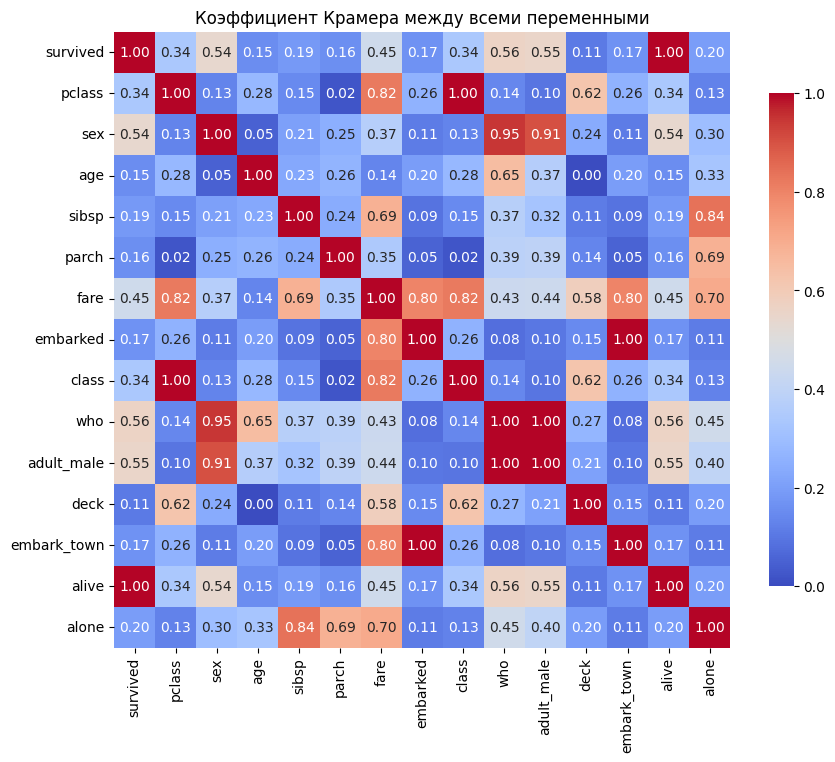

In [151]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузите данные
titanic_data = sns.load_dataset('titanic')

# Определите категориальные переменные
categorical_cols = titanic_data.columns.tolist()

# Функция для вычисления коэффициента Крамера
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - 1
    kcorr = k - 1
    return np.sqrt(phi2corr / min((kcorr, rcorr)))

# Создайте DataFrame для хранения значений коэффициента Крамера
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

# Вычислите коэффициент Крамера для каждой пары категориальных переменных
for i in range(len(categorical_cols)):
    for j in range(len(categorical_cols)):
        if i != j:
            cramers_v_matrix.iloc[i, j] = cramers_v(titanic_data[categorical_cols[i]], titanic_data[categorical_cols[j]])
        else:
            cramers_v_matrix.iloc[i, j] = 1.0  # Корреляция с самой собой

# Преобразуйте в числовой формат
cramers_v_matrix = cramers_v_matrix.astype(float)


# Визуализация матрицы корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title("Коэффициент Крамера между категориальными переменными")
plt.show()


In [22]:
tit_data = titanic_data

<Axes: >

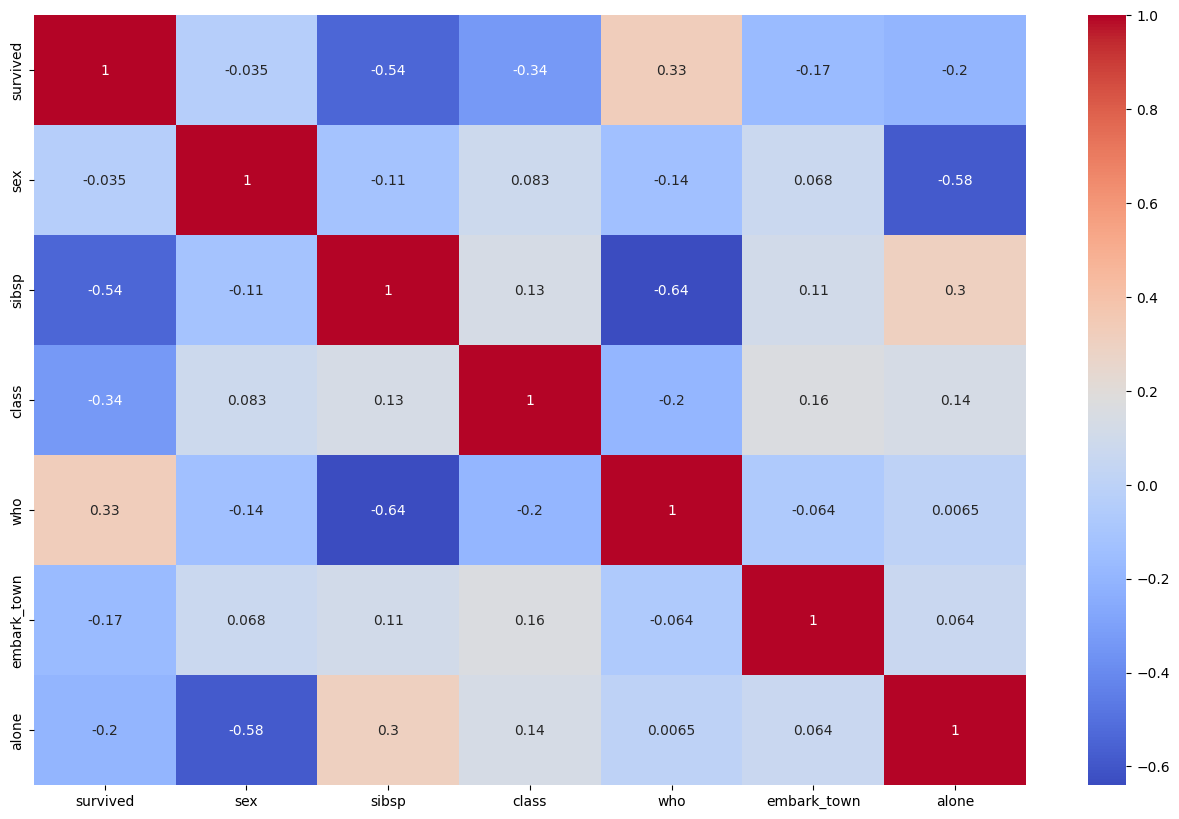

In [135]:
titanic_data = tit_data.drop(columns='age, alive, deck, embarked, fare, pclass, parch, adult_male'.split(', '))

numeric_features = titanic_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = titanic_data.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

plt.figure(figsize=(16, 10))
corr_matrix = pd.DataFrame(pipeline.fit_transform(titanic_data), columns=titanic_data.columns)
sns.heatmap(corr_matrix.corr(), annot=True, cmap='coolwarm')# age, alive, deck, embarked, fare, pclass

In [136]:
titanic_data.dtypes.unique().tolist()

[dtype('int64'),
 dtype('O'),
 CategoricalDtype(categories=['First', 'Second', 'Third'], ordered=False, categories_dtype=object),
 dtype('bool')]

# Обрабатываем данные

In [152]:
X, y = titanic_data.drop('survived', axis=1), titanic_data['survived']

In [153]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Заполнение пропусков медианой
    ('scaler', StandardScaler())  # Стандартизация
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Заполнение пропусков модой
    ('onehot', OneHotEncoder())  # Кодирование категориальных переменных
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Создание финального Pipeline (если нужно, можно добавить модель)
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Однослойная модель (без обработки выбросов)

In [154]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

In [156]:
y_train = y_train.reset_index(drop=True)

In [157]:
from sklearn.utils.class_weight import compute_class_weight

class_labels = np.unique(y)
class_weights = compute_class_weight('balanced', classes=class_labels, y=y)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(0.8114754098360656), 1: np.float64(1.3026315789473684)}


In [158]:
model = tf.keras.Sequential([
    keras.layers.Dense(128, activation='tanh', input_shape=X_train_processed[0].shape),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                    loss='binary_crossentropy',
                    metrics=['accuracy', 'precision', 'recall'])

# Обучение модели с использованием class_weight
history = model.fit(X_train_processed, y_train, 
                          epochs=20,
                          batch_size=32, 
                          validation_data=(X_test_processed, y_test),
                          class_weight=class_weights_dict)

Epoch 1/20


C:\Dev\Jupyter\dist\pyenv3.12.7-win64\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6602 - loss: 0.6515 - precision: 0.5417 - recall: 0.4774 - val_accuracy: 0.8045 - val_loss: 0.4473 - val_precision: 0.7179 - val_recall: 0.8116
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8097 - loss: 0.4112 - precision: 0.7042 - recall: 0.8117 - val_accuracy: 0.8771 - val_loss: 0.3393 - val_precision: 0.8219 - val_recall: 0.8696
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8696 - loss: 0.2998 - precision: 0.8161 - recall: 0.8708 - val_accuracy: 0.9106 - val_loss: 0.2590 - val_precision: 0.8955 - val_recall: 0.8696
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9011 - loss: 0.2466 - precision: 0.8817 - recall: 0.8555 - val_accuracy: 0.9274 - val_loss: 0.1996 - val_precision: 0.9118 - val_recall: 0.8986
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9580 - loss: 0.1691 - precision: 0.9616 - recall: 0.9221 - val_accuracy: 0.9832 - val_loss: 0.1500 - val_precision

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


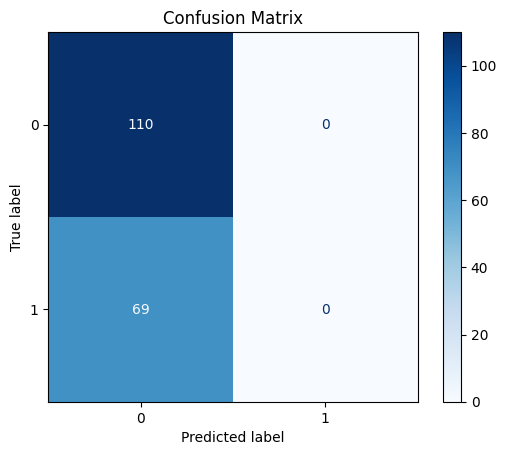

In [159]:

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
y_score = model.predict(X_test_processed)

y_pred = np.argmax(y_score, axis=1)
y_true = np.argmax(X_test_processed, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix');

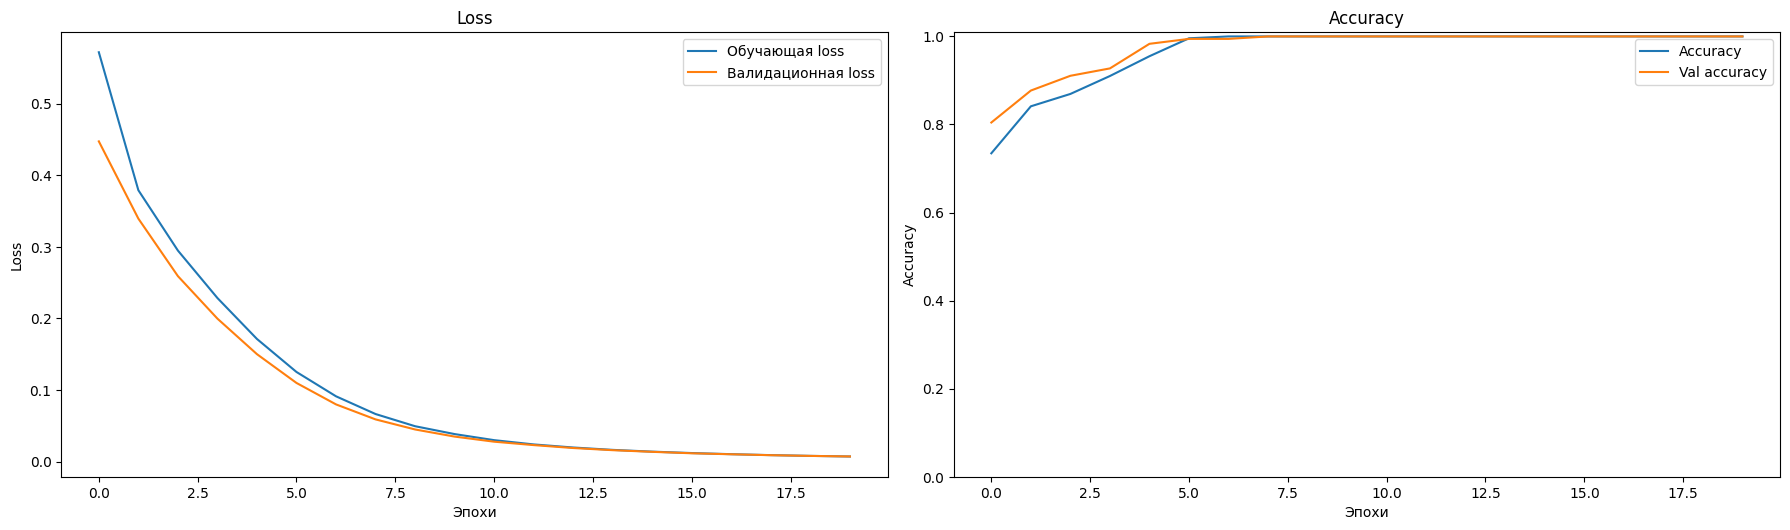

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1) 
plt.plot(history.history['loss'], label='Обучающая loss')
plt.plot(history.history['val_loss'], label='Валидационная loss')
plt.title('Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()

plt.ylim(0,1.01)

plt.tight_layout()  # автоматически подгоняет подграфики
plt.show()

# выбросы

In [161]:
X_processed = pipeline.fit_transform(X)

In [162]:
# 6. Обнаружить выбросы с использованием Z-оценки
z_scores = np.abs(stats.zscore(X_processed))
threshold = 3
outliers = (z_scores > threshold).any(axis=1)

# Удаляем выбросы
X_no_outliers = X_processed[~outliers]
y_no_outliers = y[~outliers].values

In [163]:
# 7. Обучить модель на обновлённых данных после удаления выбросов
X_train_no_outliers, X_test_no_outliers, y_train_no_outliers, y_test_no_outliers = train_test_split(X_no_outliers, y_no_outliers,
                                                                                                    test_size=0.2,
                                                                                                    random_state=42,
                                                                                                    stratify=y_no_outliers)

# Однослойная модель (с обработкой выбросов)

In [164]:
model = tf.keras.Sequential([
    keras.layers.Dense(128, activation='tanh', input_shape=X_train_no_outliers[0].shape),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                    loss='binary_crossentropy',
                    metrics=['accuracy', 'precision', 'recall'])

# Обучение модели с использованием class_weight
history = model.fit(X_train_no_outliers, y_train_no_outliers, 
                          epochs=20,
                          batch_size=32, 
                          validation_data=(X_test_no_outliers, y_test_no_outliers),
                          class_weight=class_weights_dict)

Epoch 1/20


C:\Dev\Jupyter\dist\pyenv3.12.7-win64\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5277 - loss: 0.6828 - precision: 0.2848 - recall: 0.2997 - val_accuracy: 0.8860 - val_loss: 0.4051 - val_precision: 1.0000 - val_recall: 0.6061
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8437 - loss: 0.4262 - precision: 0.9750 - recall: 0.4078 - val_accuracy: 0.9386 - val_loss: 0.3016 - val_precision: 0.9062 - val_recall: 0.8788
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8897 - loss: 0.3297 - precision: 0.8286 - recall: 0.7455 - val_accuracy: 0.9211 - val_loss: 0.2601 - val_precision: 0.8333 - val_recall: 0.9091
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8954 - loss: 0.2657 - precision: 0.8936 - recall: 0.7019 - val_accuracy: 0.9474 - val_loss: 0.2045 - val_precision: 0.8857 - val_recall: 0.9394
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9152 - loss: 0.2322 - precision: 0.9396 - recall: 0.7309 - val_accuracy: 0.9912 - val_loss: 0.1648 - val_precisio

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


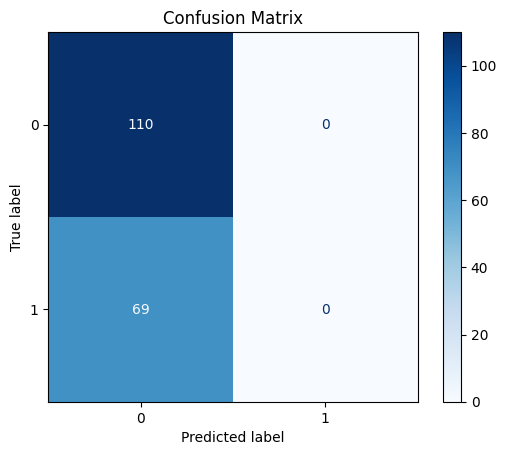

In [165]:

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
y_score = model.predict(X_test_processed)

y_pred = np.argmax(y_score, axis=1)
y_true = np.argmax(X_test_processed, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix');

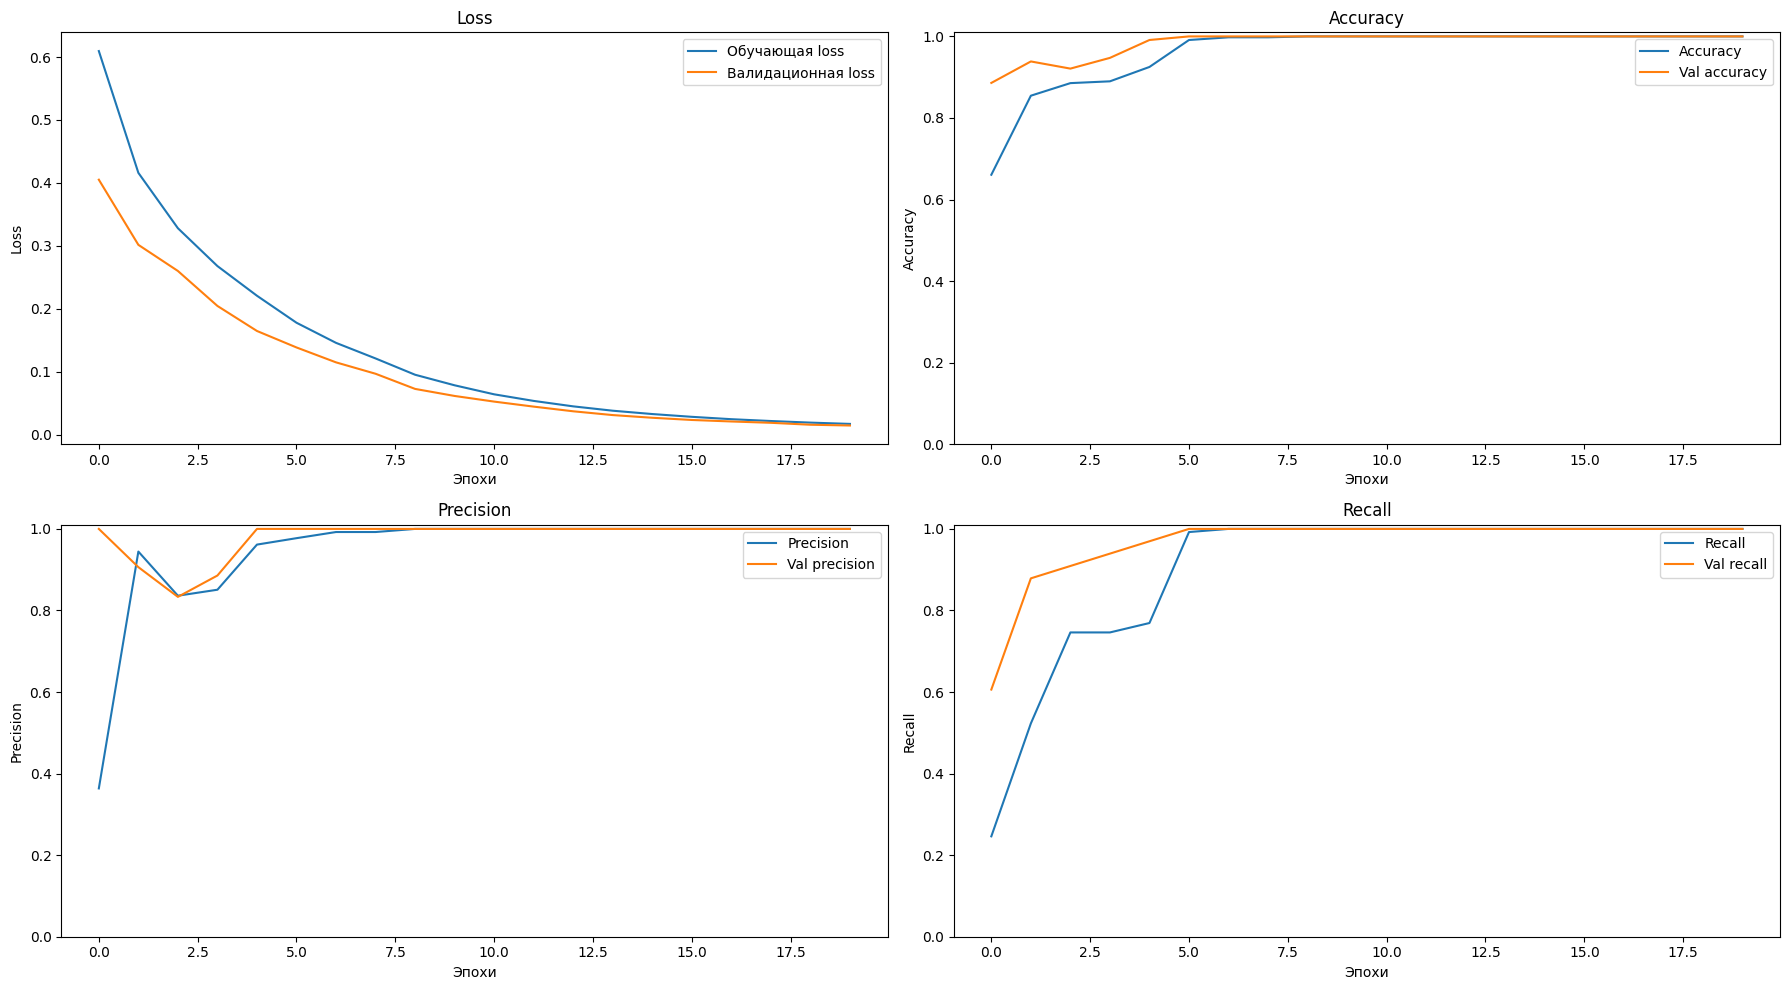

In [175]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1) 
plt.plot(history.history['loss'], label='Обучающая loss')
plt.plot(history.history['val_loss'], label='Валидационная loss')
plt.title('Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()

plt.ylim(0,1.01)

plt.subplot(2, 2, 3)
plt.plot(history.history['precision'], label='Precision')
plt.plot(history.history['val_precision'], label='Val precision')
plt.title('Precision')
plt.xlabel('Эпохи')
plt.ylabel('Precision')
plt.legend()

plt.ylim(0,1.01)

plt.subplot(2, 2, 4)
plt.plot(history.history['recall'], label='Recall')
plt.plot(history.history['val_recall'], label='Val recall')
plt.title('Recall')
plt.xlabel('Эпохи')
plt.ylabel('Recall')
plt.legend()

plt.ylim(0,1.01)

plt.tight_layout()  # автоматически подгоняет подграфики
plt.show()

# Однослойная модель без шума

In [191]:
for column in X.select_dtypes(include=['int64', 'float64']).columns.tolist():
    titanic_data[column] = median_filter(titanic_data[column].fillna(titanic_data[column].median()), size=3)

# 9. Обучить модель на обновлённых данных после фильтрации шума
X_filtered = titanic_data.drop(['survived'], axis=1)
y_filtered = titanic_data['survived']

X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(X_filtered, y_filtered.values, test_size=0.2, random_state=42)
X_train_processed = pipeline.fit_transform(X_train_filtered)
X_test_processed = pipeline.transform(X_test_filtered)


In [192]:
for a in (X_train_processed, X_test_processed, X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered):
    print(a.shape)

(712, 32)
(179, 32)
(712, 14)
(179, 14)
(712,)
(179,)


In [193]:
model = tf.keras.Sequential([
    keras.layers.Dense(128, activation='tanh', input_shape=X_train_processed[0].shape),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                    loss='binary_crossentropy',
                    metrics=['accuracy', 'precision', 'recall'])

# Обучение модели с использованием class_weight
history = model.fit(X_train_processed, y_train_filtered, 
                          epochs=20,
                          batch_size=32, 
                          validation_data=(X_test_processed, y_test_filtered),
                          class_weight=class_weights_dict)

Epoch 1/20


C:\Dev\Jupyter\dist\pyenv3.12.7-win64\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8391 - loss: 0.4929 - precision: 0.7678 - recall: 0.7949 - val_accuracy: 0.8547 - val_loss: 0.3455 - val_precision: 0.7857 - val_recall: 0.8919
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8610 - loss: 0.3200 - precision: 0.7725 - recall: 0.8535 - val_accuracy: 0.8827 - val_loss: 0.2548 - val_precision: 0.8272 - val_recall: 0.9054
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9107 - loss: 0.2431 - precision: 0.8759 - recall: 0.8790 - val_accuracy: 0.9497 - val_loss: 0.1899 - val_precision: 0.9333 - val_recall: 0.9459
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9524 - loss: 0.1754 - precision: 0.9688 - recall: 0.8888 - val_accuracy: 0.9944 - val_loss: 0.1372 - val_precision: 0.9867 - val_recall: 1.0000
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9964 - loss: 0.1312 - precision: 0.9911 - recall: 1.0000 - val_accuracy: 0.9944 - val_loss: 0.0994 - val_precision

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


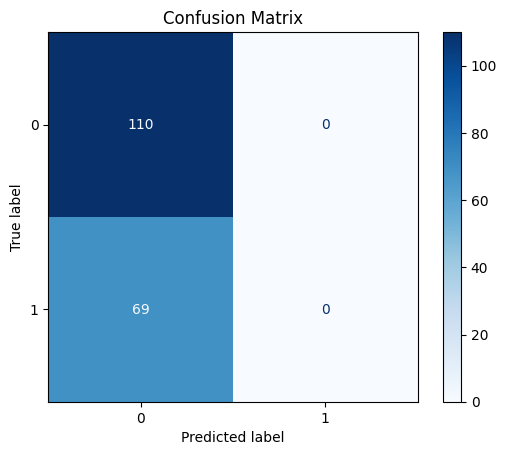

In [194]:

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
y_score = model.predict(X_test_processed)

y_pred = np.argmax(y_score, axis=1)
y_true = np.argmax(X_test_processed, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix');

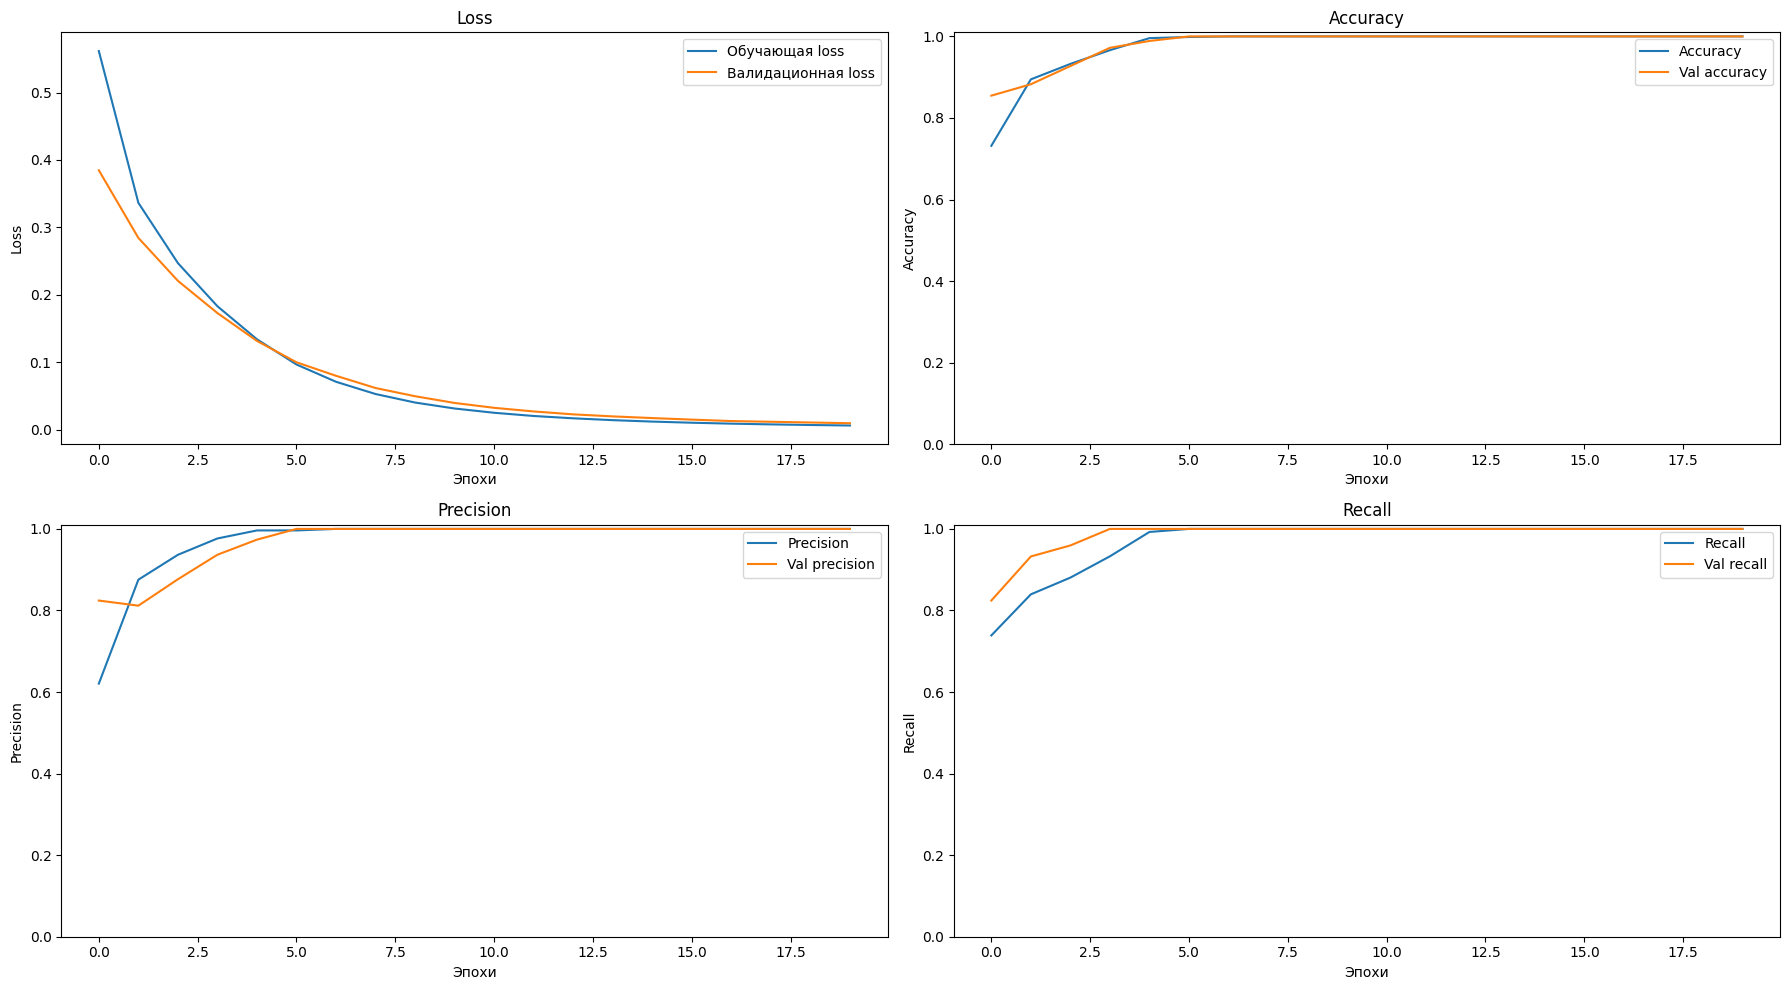

In [185]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1) 
plt.plot(history.history['loss'], label='Обучающая loss')
plt.plot(history.history['val_loss'], label='Валидационная loss')
plt.title('Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()

plt.ylim(0,1.01)

plt.subplot(2, 2, 3)
plt.plot(history.history['precision'], label='Precision')
plt.plot(history.history['val_precision'], label='Val precision')
plt.title('Precision')
plt.xlabel('Эпохи')
plt.ylabel('Precision')
plt.legend()

plt.ylim(0,1.01)

plt.subplot(2, 2, 4)
plt.plot(history.history['recall'], label='Recall')
plt.plot(history.history['val_recall'], label='Val recall')
plt.title('Recall')
plt.xlabel('Эпохи')
plt.ylabel('Recall')
plt.legend()

plt.ylim(0,1.01)

plt.tight_layout()  # автоматически подгоняет подграфики
plt.show()